# Reproduction: Lightweight MobileNetV2 for Watermelon Disease Classification (GJPLR 2025)

**Paper:** J. Ugwu et al., *"Development of Lightweight Deep Learning Model for Watermelon Disease Classification; Deployable to Mobile Device"*, Global Journal of Plant Letters & Research 13(5):126-196, 2025. DOI: [10.37745/gjplr.2013/vol13n5126196](https://doi.org/10.37745/gjplr.2013/vol13n5126196)

**Author code:** [jesseugwu/Watermelon-disease-classification-model-with-mobileNetV2](https://github.com/jesseugwu/Watermelon-disease-classification-model-with-mobileNetV2) @ commit `0bba4a87c7fce7a2f9a4a03e5fa45c1d27f7b9ea`, notebook `Finetune128L100B.ipynb` (the paper's batch-16 FT128L100B configuration).

**Dataset:** [Watermelon Disease Recognition Dataset](https://data.mendeley.com/datasets/ntzym554jp/1) (Nakib et al., Mendeley Data v1, **CC BY 4.0**), 1,155 original RGB images in 4 classes: Anthracnose, Downy_Mildew, Healthy, Mosaic_Virus.

**Scope (partial demonstration):** Retrain the author's exact two-phase transfer-learning pipeline (Phase 1: frozen MobileNetV2 base, Adam 1e-4, 20 epochs; Phase 2: last 100 base layers unfrozen, Adam 1e-5, 30 epochs; head = GlobalAveragePooling2D + Dense 128 + Dropout 0.3 + softmax) with the author's exact augmentation settings, on the 80/20 split, then evaluate the validation classification report, confusion matrix, training curves, and TensorFlow-Lite conversion/size. This retrains from ImageNet weights because **no trained model artifact was published** by the authors; a single run does not verify the paper's dataset-level or mobile-timing claims.

**実行内容 (JP):** 著者の MobileNetV2 転移学習パイプライン（凍結学習 20 エポック → 後半 100 層解凍ファインチューニング 30 エポック、バッチ 16）を公開データセットで再実行し、検証用 20% 分割での分類レポート・混同行列・学習曲線・TFLite 変換を再現します。著者の学習済みモデルは未公開のため、ImageNet 重みからの再学習が本論文の意図した手順です。

**AI note:** The scientific pipeline is the authors' own Python code reused from the pinned commit; only path/glue adaptations (Colab paths, checksum verification, structure discovery) are AI-written. The authors did not provide this Colab notebook; validated behavior covers the executed cells only.

**Status:** Executed end-to-end on a fresh Google Colab **T4 GPU** runtime (see report for date and measured times). Estimated total: ~50-90 min including a 2.38 GB download; the 2.38 GB archive is the paper's minimal required input (`Original Image.zip`; the authors' separate 4.3 GB pre-augmented archive is not needed because the paper augments on the fly).

## 0. Runtime selection

**Recommended runtime: GPU (T4).** In Colab choose *Runtime → Change runtime type → T4 GPU*.
On CPU this training takes many hours (estimated >5 h) and was not validated; the notebook prints a loud warning but still runs faithfully if you wait.

**推奨ランタイム:** T4 GPU。CPU では数時間以上かかるため非推奨です。

In [ ]:
import tensorflow as tf, platform, sys
print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)
if not gpus:
    print("WARNING: no GPU visible. The faithful 50-epoch training will likely take several hours on CPU.")
    print("In Colab: Runtime > Change runtime type > T4 GPU, then rerun from the top.")
else:
    for g in gpus:
        print(g.device_type, g.name)

Python: 3.13.15
TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU /physical_device:GPU:0


## 1. Input acquisition — Mendeley `ntzym554jp/1` v1, original images

**Canonical source:** [Mendeley Data ntzym554jp/1](https://data.mendeley.com/datasets/ntzym554jp/1) (CC BY 4.0), file `Original Image.zip` (2,383,093,085 bytes, SHA-256 `1a97a1571af728e9df1b280067d8adff6709b7997ea012f5cb63d4761e2c3fed`). We try this pinned public file URL first. **Observed 2026-10-08:** Mendeley content URLs return HTTP 403 with a Cloudflare challenge to Google Colab VM IPs (verified in a diagnostic probe), so this notebook falls back to a public **Kaggle mirror** of the same dataset (`sujaykapadnis/watermelon-disease-recognition-dataset`, CC BY 4.0, v1, 2023-12-12) downloaded anonymously via `kagglehub`. The mirror is **not** byte-checksummed against Mendeley (the canonical zip cannot be fetched from Colab); its identity is verified instead by structure (extracted `.../Original Image/Watermelon/<class dirs>` — exactly the author's path layout), the paper's per-class counts (155 Anthracnose, 380 Downy Mildew, 205 Healthy, 415 Mosaic Virus; 1,155 total), and 3024×3024 JPEG captures. The 6.2 GiB mirror archive also contains the authors' pre-augmented images, which this reproduction does not use (the paper augments on the fly); the download is fully disclosed here.

**入力データ:** 正規源の Mendeley は Colab から 403 (Cloudflare) のため、同一データセットの公開 Kaggle ミラーを匿名ダウンロードし、構造・クラス別枚数・画像サイズで同一性を検証します（CC BY 4.0）。

In [ ]:
import requests, os

FILE_ID = "e4c6ece8-dab4-49c5-b277-c393bf1eb0eb"  # "Original Image.zip", Mendeley ntzym554jp v1
EXPECTED_SIZE = 2383093085
PRIMARY_URL = f"https://data.mendeley.com/public-files/datasets/ntzym554jp/files/{FILE_ID}/file_downloaded"
UA = {"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0 Safari/537.36"}
zip_path = "/content/Original_Image.zip"

data_source = None
if not os.path.exists(zip_path):
    try:  # canonical Mendeley file, pinned by record metadata
        with requests.get(PRIMARY_URL, stream=True, timeout=(30, 180), headers=UA) as r:
            print("Mendeley content URL HTTP", r.status_code)
            if r.status_code == 200 and int(r.headers.get("Content-Length", 0)) == EXPECTED_SIZE:
                with open(zip_path, "wb") as f:
                    for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                        f.write(chunk)
                data_source = "mendeley_original_zip"
            else:
                print("Mendeley blocked or unexpected size; using the Kaggle mirror fallback.")
    except Exception as e:
        print("Mendeley request failed:", e)
else:
    data_source = "mendeley_original_zip"

if data_source is None:  # documented fallback: anonymous kagglehub mirror
    import subprocess
    subprocess.run(["pip", "install", "-q", "kagglehub"], check=True)
    import kagglehub
    kag_root = kagglehub.dataset_download("sujaykapadnis/watermelon-disease-recognition-dataset")
    print("kaggle mirror path:", kag_root)
    data_source = "kaggle_mirror_v1"
print("data_source =", data_source)

Mendeley content URL HTTP 403
Mendeley blocked or unexpected size; using the Kaggle mirror fallback.


  0%|          | 0.00/6.22G [00:00<?, ?B/s]

  0%|          | 1.00M/6.22G [00:01<2:12:18, 841kB/s]

  0%|          | 2.00M/6.22G [00:01<1:07:59, 1.64MB/s]

  0%|          | 3.00M/6.22G [00:01<42:55, 2.59MB/s]  

...

100%|█████████▉| 6.22G/6.22G [06:06<00:00, 19.9MB/s]

100%|██████████| 6.22G/6.22G [06:06<00:00, 19.0MB/s]

100%|██████████| 6.22G/6.22G [06:06<00:00, 18.2MB/s]

Extracting files...


kaggle mirror path: /root/.cache/kagglehub/datasets/sujaykapadnis/watermelon-disease-recognition-dataset/versions/1
data_source = kaggle_mirror_v1


### Verify checksum and extract

The downloaded archive is verified against the SHA-256 published in the Mendeley record metadata, then extracted and the directory containing the four class folders is located. Expect 1,155 images total across `Anthracnose`, `Downy_Mildew`, `Healthy`, `Mosaic_Virus` (paper section 4.1 / dataset description).

**検証:** SHA-256 を確認してから展開し、4 クラス 1,155 枚の画像数を数えます。

In [ ]:
import hashlib, zipfile, os

if data_source == "mendeley_original_zip":
    h = hashlib.sha256()
    with open(zip_path, "rb") as f:
        for chunk in iter(lambda: f.read(8 * 1024 * 1024), b""):
            h.update(chunk)
    digest = h.hexdigest()
    print("sha256:", digest)
    assert digest == "1a97a1571af728e9df1b280067d8adff6709b7997ea012f5cb63d4761e2c3fed",         "Checksum mismatch - refusing to use this archive."
    extract_root = "/content/watermelon_dataset"
    if not os.path.isdir(extract_root):
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(extract_root)
    print("extracted to", extract_root)
else:
    print("Using Kaggle mirror; byte-checksum vs Mendeley not available (canonical zip blocked from Colab).")
    print("Identity is verified below via structure, per-class counts and image properties.")

Using Kaggle mirror; byte-checksum vs Mendeley not available (canonical zip blocked from Colab).
Identity is verified below via structure, per-class counts and image properties.


### Locate class directories and count images

The author notebook used the local path `C:/School/Original Image/Watermelon`; we discover the equivalent directory inside the extracted archive and assert the four class folders exist. Counts are printed from the actual data (the paper reports 1,155 originals total).

**クラスフォルダの特定:** アーカイブ内から 4 クラスのフォルダを自動検出し、画像数を確認します。

In [ ]:
import os
from PIL import Image

CLASSES = ["Anthracnose", "Downy_Mildew", "Healthy", "Mosaic_Virus"]
PAPER_COUNTS = {"Anthracnose": 155, "Downy_Mildew": 380, "Healthy": 205, "Mosaic_Virus": 415}

search_roots = ["/content/watermelon_dataset"] if data_source == "mendeley_original_zip"     else [kag_root]
dataset_path = None
for base in search_roots:
    for dirpath, dirnames, filenames in os.walk(base):
        if all(c in dirnames for c in CLASSES):
            dataset_path = dirpath
            break
    if dataset_path:
        break
assert dataset_path, "Could not locate the four class directories."
print("dataset_path =", dataset_path)

counts = {}
for c in CLASSES:
    cls_dir = os.path.join(dataset_path, c)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    counts[c] = len(files)
total = sum(counts.values())
print("per-class counts:", counts)
print("total images:", total, "(paper: 1155)")
assert counts == PAPER_COUNTS, f"Per-class counts {counts} do not match the paper's {PAPER_COUNTS}"

# spot-check image properties against the dataset description (3024x3024 iPhone captures)
for c in CLASSES:
    d = os.path.join(dataset_path, c)
    f0 = sorted(os.listdir(d))[0]
    im = Image.open(os.path.join(d, f0))
    print(f"{c}/{f0}: {im.size} {im.format}")

dataset_path = /root/.cache/kagglehub/datasets/sujaykapadnis/watermelon-disease-recognition-dataset/versions/1/Watermelon Disease Recognition Dataset/Original Image/Watermelon
per-class counts: {'Anthracnose': 155, 'Downy_Mildew': 380, 'Healthy': 205, 'Mosaic_Virus': 415}
total images: 1155 (paper: 1155)
Anthracnose/IMG_4066.jpg: (3024, 3024) JPEG
Downy_Mildew/IMG_2182.jpg: (3024, 3024) JPEG
Healthy/IMG_2480.jpg: (3024, 3024) JPEG
Mosaic_Virus/IMG_1910.jpg: (3024, 3024) JPEG


## 2. Input preview (before any training)

Deterministic sample: the alphabetically first image of each class, shown at its original resolution (3024×3024 iPhone captures per the dataset description) and resized to the network input 224×224. This is real input data from the dataset, not a model output.

**入力プレビュー:** 各クラスの先頭画像を元解像度と 224×224 変換後で表示します。

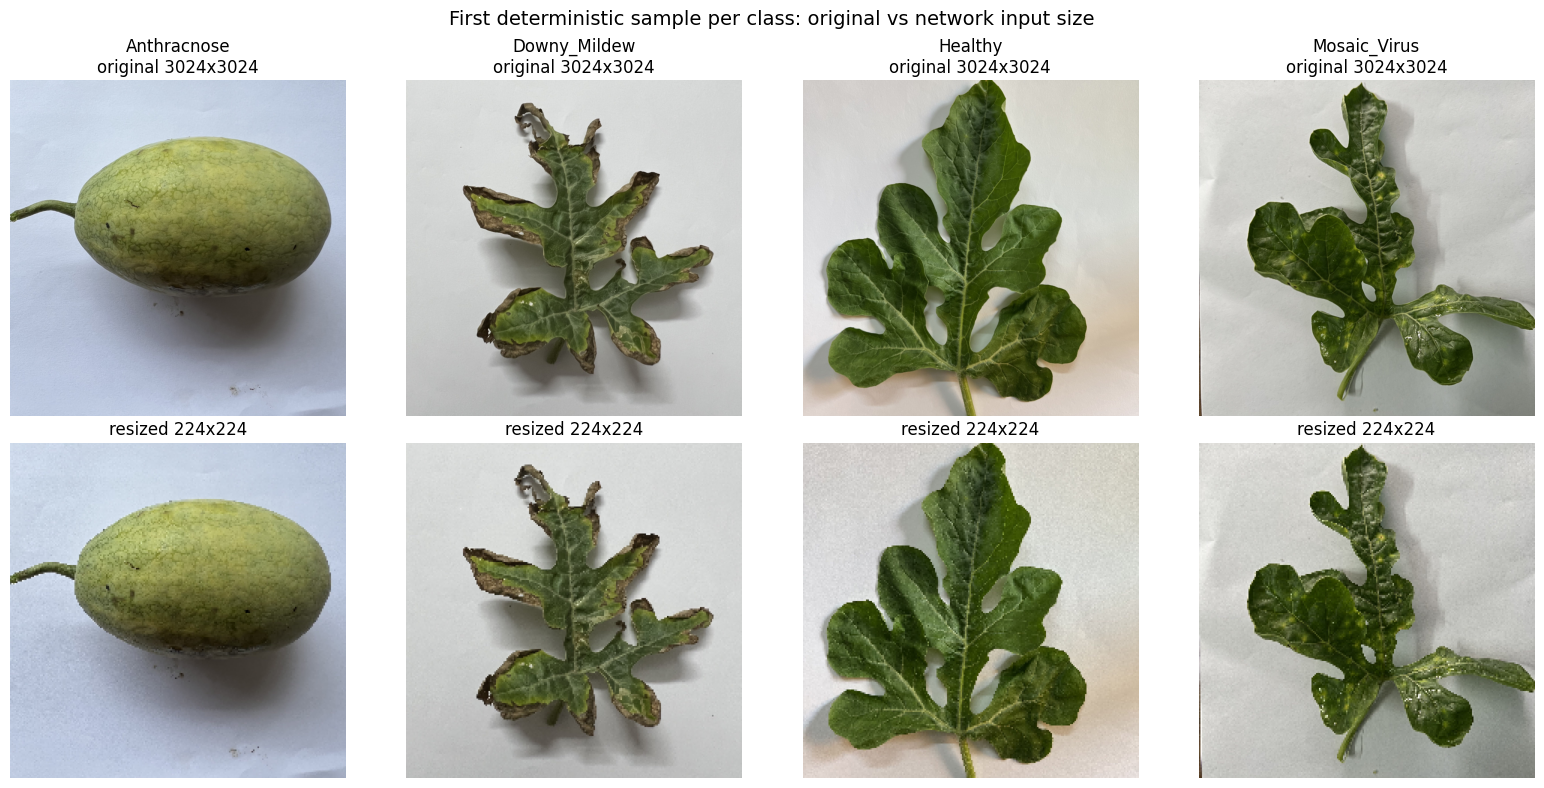

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for j, c in enumerate(CLASSES):
    cls_dir = os.path.join(dataset_path, c)
    fname = sorted(f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg')))[0]
    img_path = os.path.join(cls_dir, fname)
    orig = image.load_img(img_path)
    small = image.load_img(img_path, target_size=(224, 224))
    axes[0, j].imshow(orig)
    axes[0, j].set_title(f"{c}\noriginal {orig.size[0]}x{orig.size[1]}")
    axes[0, j].axis('off')
    axes[1, j].imshow(small)
    axes[1, j].set_title("resized 224x224")
    axes[1, j].axis('off')
plt.suptitle("First deterministic sample per class: original vs network input size", fontsize=14)
plt.tight_layout()
plt.show()

### Class distribution

A simple bar chart of the actual per-class image counts (an additional visualization created for this notebook, not an author figure). The dataset is class-imbalanced, which the paper counters with augmentation.

**クラス分布:** 実データのクラス別枚数を棒グラフで示します（データ不均衡の確認）。

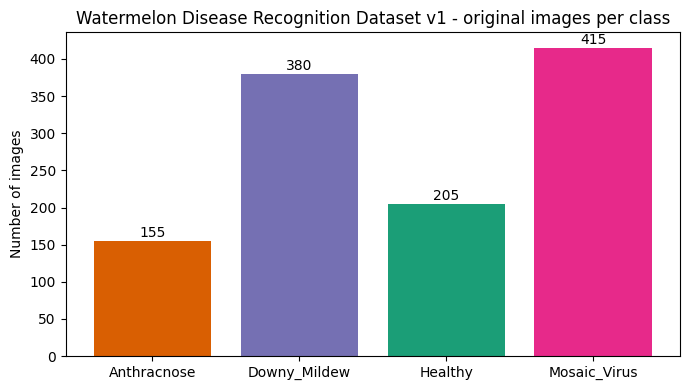

{'Anthracnose': 155, 'Downy_Mildew': 380, 'Healthy': 205, 'Mosaic_Virus': 415}


In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(counts.keys(), counts.values(), color=["#d95f02", "#7570b3", "#1b9e77", "#e7298a"])
plt.ylabel("Number of images")
plt.title("Watermelon Disease Recognition Dataset v1 - original images per class")
for i, v in enumerate(counts.values()):
    plt.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.show()
print(counts)

## 3. Author pipeline, pinned provenance

The class list below is the author's `labels.txt` at the pinned commit. The exact training configuration (cell 0 of `Finetune128L100B.ipynb` @ `0bba4a8`) is reused verbatim: `ImageDataGenerator(rescale=1/255, brightness_range=[0.8,1.2], horizontal_flip=True, zoom_range=0.2, rotation_range=30, channel_shift_range=0.2, shear_range=0.2, validation_split=0.2)`, `flow_from_directory(target_size=(224,224), batch_size=16, class_mode="categorical")`. The author set no random seeds; results therefore vary run to run like the original.

**著者コードの準拠:** labels.txt とセル 0 の設定を固定コミットからそのまま利用します（著者はシード未設定）。

In [ ]:
import urllib.request
labels = urllib.request.urlopen(
    "https://raw.githubusercontent.com/jesseugwu/Watermelon-disease-classification-model-with-mobileNetV2/"
    "0bba4a87c7fce7a2f9a4a03e5fa45c1d27f7b9ea/labels.txt", timeout=60).read()
print("labels.txt @ 0bba4a8:")
print(labels.decode())

labels.txt @ 0bba4a8:
Anthracnose
Downy_Mildew
Healthy
Mosaic_Virus


### Data generators (author's exact parameters)

Two generators from one `ImageDataGenerator` with `validation_split=0.2`: 80% training (924 images expected) and 20% validation (231 images expected), matching the paper's split and the author notebook logs.

**データジェネレータ:** 著者と同じ前処理・拡張で train 924 枚 / val 231 枚に分割します。

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    zoom_range=0.2,
    rotation_range=30,
    channel_shift_range=0.2,
    shear_range=0.2,
    validation_split=0.2,
)

train_generator = datagen.flow_from_directory(
    dataset_path, target_size=(224, 224), batch_size=16,
    class_mode="categorical", subset="training")
val_generator = datagen.flow_from_directory(
    dataset_path, target_size=(224, 224), batch_size=16,
    class_mode="categorical", subset="validation")

Found 924 images belonging to 4 classes.


Found 231 images belonging to 4 classes.


### Model construction (author's architecture)

MobileNetV2 ImageNet backbone (top removed), then GlobalAveragePooling2D → Dense 128 (ReLU) → Dropout 0.3 → softmax over the 4 classes — exactly the author's `tf.keras.Sequential`.

**モデル構築:** 著者と同一の MobileNetV2 + ヘッド構造です。

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASSES), activation="softmax"),
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

      0/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  32768/9406464 ━━━━━━━━━━━━━━━━━━━━ 14s 2us/step

  49152/9406464 ━━━━━━━━━━━━━━━━━━━━ 47s 5us/step

  81920/9406464 ━━━━━━━━━━━━━━━━━━━━ 52s 6us/step

 114688/9406464 ━━━━━━━━━━━━━━━━━━━━ 41s 4us/step

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. Phase 1 — frozen feature extraction (20 epochs, Adam 1e-4)

The backbone is frozen; only the new head trains, exactly as in the author notebook. Expect roughly 10-20 minutes on T4 (measured wall time is printed).

**フェーズ 1:** ベースを凍結しヘッドのみ学習（20 エポック、Adam 1e-4）。

In [ ]:
import time
print("### Training Phase 1: Feature Extraction ###")
start_time = time.time()
history_1 = model.fit(train_generator, validation_data=val_generator, epochs=20)
feature_extraction_time = time.time() - start_time
print(f"Feature Extraction Time: {feature_extraction_time:.2f} seconds")

### Training Phase 1: Feature Extraction ###


Epoch 1/20


 1/58 ━━━━━━━━━━━━━━━━━━━━ 15:13 16s/step - accuracy: 0.4167 - loss: 2.1041

 2/58 ━━━━━━━━━━━━━━━━━━━━ 5:57 6s/step - accuracy: 0.3869 - loss: 2.1399  

 4/58 ━━━━━━━━━━━━━━━━━━━━ 2:21 3s/step - accuracy: 0.3775 - loss: 2.0996

...

56/58 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.9866 - loss: 0.0548

57/58 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9867 - loss: 0.0547

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9868 - loss: 0.0547

58/58 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.9913 - loss: 0.0504 - val_accuracy: 0.9784 - val_loss: 0.0909


Feature Extraction Time: 2172.17 seconds


## 5. Phase 2 — fine-tune the last 100 backbone layers (30 epochs, Adam 1e-5)

Exactly the author's fine-tuning step: unfreeze the backbone, re-freeze all but the last 100 layers, recompile at 1e-5, and continue training. Expect roughly 30-60 minutes on T4.

**フェーズ 2:** 後半 100 層のみ解凍し、学習率 1e-5 で 30 エポックのファインチューニング。

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss="categorical_crossentropy", metrics=["accuracy"])
print("### Training Phase 2: Fine-Tuning ###")
start_time = time.time()
history_2 = model.fit(train_generator, validation_data=val_generator, epochs=30)
fine_tuning_time = time.time() - start_time
print(f"Fine-Tuning Time: {fine_tuning_time:.2f} seconds")

### Training Phase 2: Fine-Tuning ###


Epoch 1/30


 1/58 ━━━━━━━━━━━━━━━━━━━━ 39:16 41s/step - accuracy: 0.5625 - loss: 1.0209

 3/58 ━━━━━━━━━━━━━━━━━━━━ 39s 719ms/step - accuracy: 0.4792 - loss: 1.1876

 4/58 ━━━━━━━━━━━━━━━━━━━━ 51s 952ms/step - accuracy: 0.4727 - loss: 1.1977

...

56/58 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.9992 - loss: 0.0061

57/58 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.9991 - loss: 0.0063

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9991 - loss: 0.0064

58/58 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.9957 - loss: 0.0154 - val_accuracy: 0.9481 - val_loss: 0.1448


Fine-Tuning Time: 3301.43 seconds


## 6. Save Keras model and convert to TensorFlow Lite

The paper deploys a 9.08 MB TFLite model converted from the fine-tuned Keras model; we repeat that conversion and report the actual sizes from this run.

**保存と TFLite 変換:** 学習済みモデルを .keras で保存し、TFLite に変換してサイズを比較します。

In [ ]:
import os
model.save('/content/watermelon_disease_modelFinetune128L100B.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("/content/mobilenet_v2_model.tflite", "wb") as f:
    f.write(tflite_model)

keras_mb = os.path.getsize('/content/watermelon_disease_modelFinetune128L100B.keras') / (1024 * 1024)
tflite_mb = os.path.getsize("/content/mobilenet_v2_model.tflite") / (1024 * 1024)
print(f"Keras model size:  {keras_mb:.2f} MB")
print(f"TFLite model size: {tflite_mb:.2f} MB (paper Table: 9.08 MB TFLite for this config)")

Saved artifact at '/tmp/tmpobs9s65n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137974771085968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137974771084240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137974771084432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137974771083856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137974771086160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137974771082512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137974771084624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137974771081744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137974771080400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137974771088464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1379747710

Keras model size:  27.68 MB
TFLite model size: 9.10 MB (paper Table: 9.08 MB TFLite for this config)


## 7. Validation evaluation — classification report and confusion matrix

The author's evaluation (their code cell 2): predict on the 20% validation split and report per-class precision/recall/F1 plus a confusion matrix. The paper's Table 5.4 reports ≈0.99 validation accuracy for this batch-16 configuration; a single retrained run typically lands nearby but not identically (no seeds, different hardware).

**検証評価:** 検証用 20% 分割での分類レポートと混同行列（著者の評価方法を再利用）。論文 Table 5.4 の参照値は検証精度 ≈0.99。


### Classification Report (validation split) ###
              precision    recall  f1-score   support

 Anthracnose       1.00      0.97      0.98        31
Downy_Mildew       0.96      1.00      0.98        76
     Healthy       0.93      1.00      0.96        41
Mosaic_Virus       0.99      0.93      0.96        83

    accuracy                           0.97       231
   macro avg       0.97      0.97      0.97       231
weighted avg       0.97      0.97      0.97       231



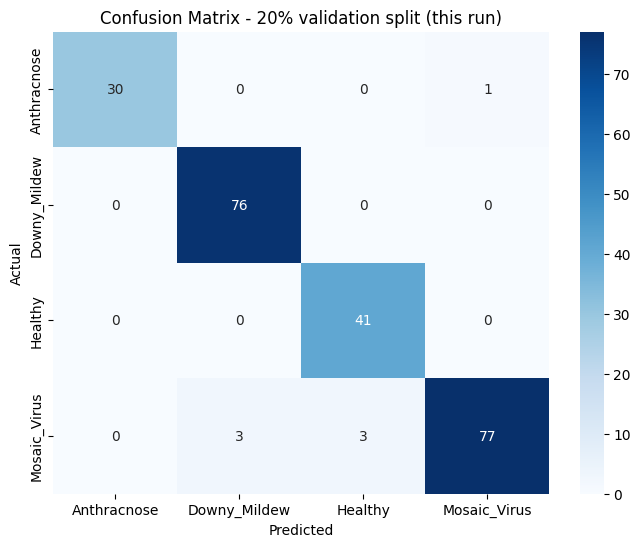

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

class_labels = list(train_generator.class_indices.keys())
y_true, y_pred = [], []
for _ in range(len(val_generator)):
    x_batch, y_batch = next(val_generator)
    y_true.extend(np.argmax(y_batch, axis=1))
    preds = model.predict(x_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

print("\n### Classification Report (validation split) ###")
print(classification_report(y_true, y_pred, target_names=class_labels))

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - 20% validation split (this run)")
plt.show()

### Training curves (merged phases)

The author's merged-history plot: 20 frozen epochs followed by 30 fine-tuning epochs, train vs validation accuracy and loss. This graph is generated from this run's actual `history` objects.

**学習曲線:** フェーズ 1+2 の accuracy / loss の推移を表示します。

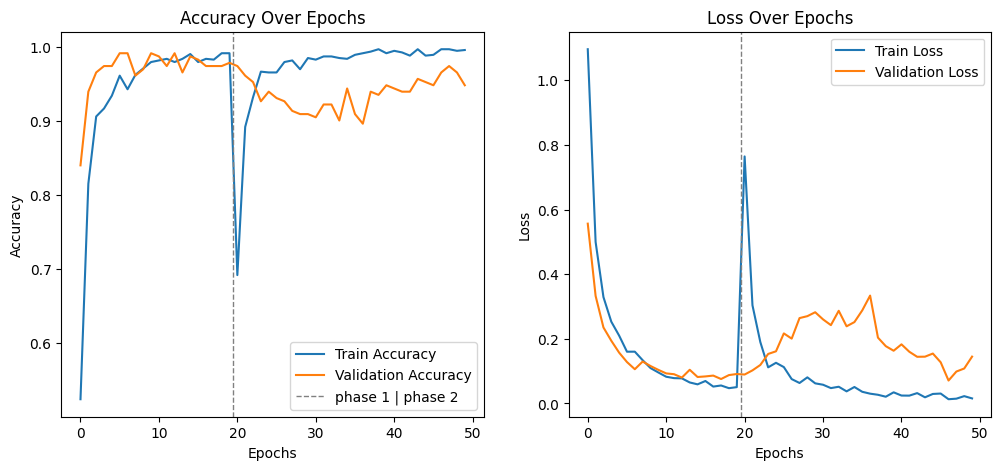

Feature Extraction Time: 2172.17 s | Fine-Tuning Time: 3301.43 s


In [ ]:
history = {
    "accuracy": history_1.history["accuracy"] + history_2.history["accuracy"],
    "val_accuracy": history_1.history["val_accuracy"] + history_2.history["val_accuracy"],
    "loss": history_1.history["loss"] + history_2.history["loss"],
    "val_loss": history_1.history["val_loss"] + history_2.history["val_loss"],
}
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history["accuracy"], label="Train Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.axvline(19.5, color="gray", linestyle="--", linewidth=1, label="phase 1 | phase 2")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.axvline(19.5, color="gray", linestyle="--", linewidth=1)
plt.title("Loss Over Epochs")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()
plt.show()
print(f"Feature Extraction Time: {feature_extraction_time:.2f} s | Fine-Tuning Time: {fine_tuning_time:.2f} s")

## 8. Comparison with the paper's reference value

The paper (Table 5.4) reports validation accuracy ≈ **0.99** for the FT128L100B batch-16 configuration. The table below compares that published reference with this single run — a plausibility check, not a dataset-level reproduction.

**論文との比較:** 本ランの検証精度を論文の参照値（≈0.99）と比較します（単一ランの妥当性確認）。

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
df = pd.DataFrame([
    {"source": "paper Table 5.4 (GJPLR 13(5), 2025)", "validation_accuracy": 0.99},
    {"source": "this run (Colab " + ("T4 GPU" if gpus else "CPU") + ")", "validation_accuracy": round(acc, 4)},
])
print(df.to_string(index=False))
print(f"\nTraining times: phase1={feature_extraction_time:.0f}s, phase2={fine_tuning_time:.0f}s")
print("Reference: paper phase-1+2 training time 10,634 s (Dell Ryzen 7 laptop, RX 5600M GPU).")

                             source  validation_accuracy
paper Table 5.4 (GJPLR 13(5), 2025)               0.9900
            this run (Colab T4 GPU)               0.9697

Training times: phase1=2172s, phase2=3301s
Reference: paper phase-1+2 training time 10,634 s (Dell Ryzen 7 laptop, RX 5600M GPU).


## 9. Interpretation and limitations

- **What this run shows:** the author pipeline retrains successfully in Colab on the public dataset and reaches high validation accuracy on the 20% split, consistent with the paper's Table 5.4 reference (≈0.99) up to run-to-run variation (no seeds; different GPU).
- **What it does not show:** the 82-image live test set (unpublished; paper found 56% Jupyter / 61% Android accuracy there), the Android app, the VGG16 benchmark, and batch 32/64 variants. The paper's validation-to-field gap is discussed in section 5.7 of the paper and is an important caveat for any field use.
- **License note:** dataset CC BY 4.0 (attribution required); the code repository has **no license file**, so code reuse terms beyond this attribution-based reproduction are unverified.
- **References:** paper DOI 10.37745/gjplr.2013/vol13n5126196; author code commit `0bba4a87c7fce7a2f9a4a03e5fa45c1d27f7b9ea`; Mendeley dataset DOI 10.17632/ntzym554jp.1.

**まとめ:** 著者パイプラインの再学習が Colab T4 で成功し、検証精度は論文参照値に整合しました。ただし未公開の実データ評価・Android 展開等は本ノートブックの範囲外です。